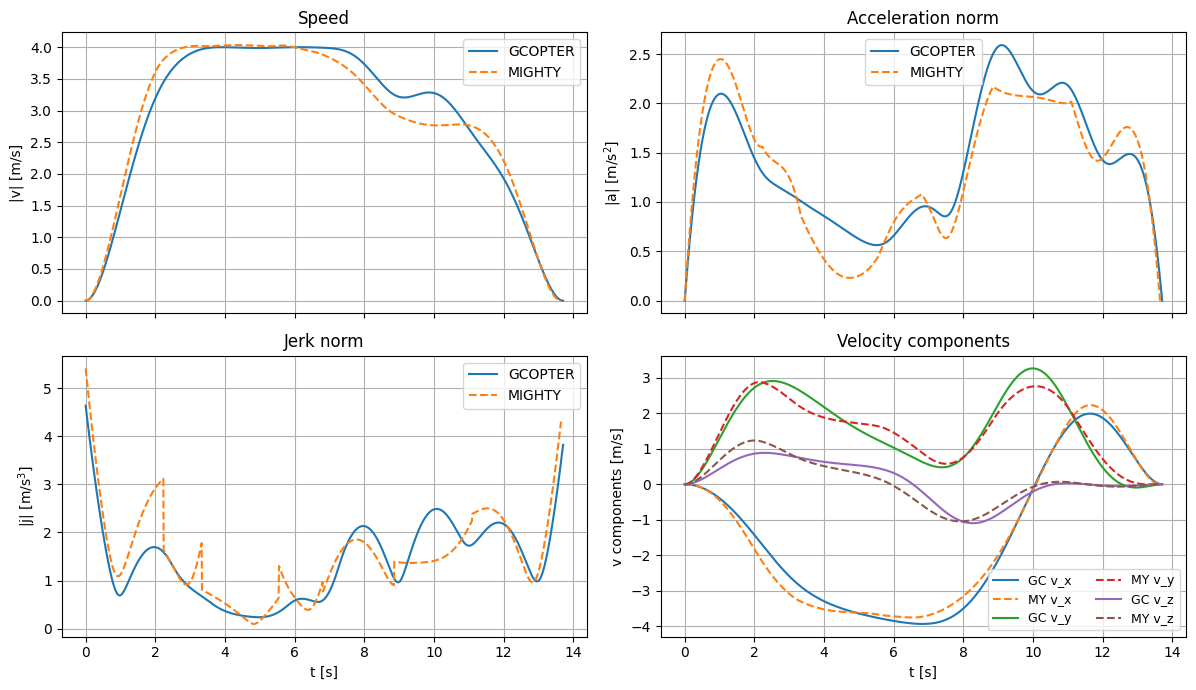

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Where the C++ node wrote CSVs
LOG_DIR = Path("/home/kkondo/data/gcopter_csv")   # <- change if needed
f_gc = LOG_DIR / "gcopter_vaj.csv"
f_my = LOG_DIR / "mighty_vaj.csv"

gc = pd.read_csv(f_gc)
my = pd.read_csv(f_my)

# Ensure same time range for nicer overlays (optional)
# tmax = min(gc['t'].max(), my['t'].max())
# gc = gc[gc['t'] <= tmax].copy()
# my = my[my['t'] <= tmax].copy()

# 2x2 figure:
# TL: speed, TR: |acc|, BL: |jerk|, BR: velocity components (x/y/z) for both
fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
(ax11, ax12), (ax21, ax22) = ax

# Speed
ax11.plot(gc['t'], gc['v_norm'], label='GCOPTER')
ax11.plot(my['t'], my['v_norm'], linestyle='--', label='MIGHTY')
ax11.set_ylabel('|v| [m/s]')
ax11.set_title('Speed')
ax11.grid(True); ax11.legend()

# Acceleration norm
ax12.plot(gc['t'], gc['a_norm'], label='GCOPTER')
ax12.plot(my['t'], my['a_norm'], linestyle='--', label='MIGHTY')
ax12.set_ylabel('|a| [m/s$^2$]')
ax12.set_title('Acceleration norm')
ax12.grid(True); ax12.legend()

# Jerk norm
ax21.plot(gc['t'], gc['j_norm'], label='GCOPTER')
ax21.plot(my['t'], my['j_norm'], linestyle='--', label='MIGHTY')
ax21.set_xlabel('t [s]')
ax21.set_ylabel('|j| [m/s$^3$]')
ax21.set_title('Jerk norm')
ax21.grid(True); ax21.legend()

# Velocity components
for comp, lab in zip(['vx','vy','vz'], ['v_x','v_y','v_z']):
    ax22.plot(gc['t'], gc[comp], label=f'GC {lab}')
    ax22.plot(my['t'], my[comp], linestyle='--', label=f'MY {lab}')
ax22.set_xlabel('t [s]')
ax22.set_ylabel('v components [m/s]')
ax22.set_title('Velocity components')
ax22.grid(True); ax22.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


In [3]:
import numpy as np
CP = np.array([[17.9634,17.3252,1.6992],
               [18.8730,18.4613,1.42155],
               [19.6798,19.5047,1.15361],
               [20.0000,20.0000,1.00000],
               [20.0000,20.0000,1.00000],
               [20.0000,20.0000,1.00000]])
T = 1.91652
v_end = 5.0/T*(CP[5]-CP[4])
a_end = 20.0/(T*T)*(CP[5]-2*CP[4]+CP[3])
print("v_end:", v_end, "||", np.linalg.norm(v_end))
print("a_end:", a_end, "||", np.linalg.norm(a_end))


v_end: [0. 0. 0.] || 0.0
a_end: [0. 0. 0.] || 0.0
